In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv(r"C:\Users\Admin\Downloads\20220801_rawdata\TC_filtered_final.csv")
df

,Formula,Temperature (K),TC,DOI
0,Ag0.003Bi2Te2.7Se0.3,300.269397,1.344737,10.1016/j.mtphys.2017.09.001
1,Ag0.003Bi2Te2.7Se0.3,323.976293,1.284211,10.1016/j.mtphys.2017.09.001
2,Ag0.003Bi2Te2.7Se0.3,349.838362,1.234211,10.1016/j.mtphys.2017.09.001
3,Ag0.003Bi2Te2.7Se0.3,375.161638,1.215789,10.1016/j.mtphys.2017.09.001
4,Ag0.003Bi2Te2.7Se0.3,399.946121,1.217105,10.1016/j.mtphys.2017.09.001
...,...,...,...,...
99767,Zr3Ni3Sb4,768.687717,3.475678,10.1063/1.4869573
99768,Zr3Ni3Sb4,772.047833,2.889204,10.1016/j.mtphys.2017.08.002
99769,Zr3Ni3Sb4,824.607103,3.618427,10.1063/1.4869573
99770,Zr3Ni3Sb4,866.927280,3.527755,10.1063/1.4928168


   Element  Count
0       Sb  44321
1       Te  27478
2       Co  23060
3       Bi  22161
4       Se  15153
5       Cu  12912
6        O  12663
7       Sn  11906
8       Ba  11265
9       Fe  10680
10      Ge  10581
11      Ca  10064
12       S  10029
13      In   9700
14      Si   9281
15      Pb   8437
16      Mg   8308
17      Zn   8155
18      Ni   6883
19      Yb   6631
20      Ga   6063
21      Mn   4874
22      Sr   4213
23      La   3903
24      Al   3791
25      Ce   3776
26      Na   3488
27      Ag   3249
28      Ti   3213
29      Nb   2761
30      Cr   2036
31      Mo   1874
32       V   1844
33      Cl   1645
34       I   1633
35      Eu   1606
36      Cd   1442
37       Y   1261
38      Nd   1029
39      Sm    859
40      Gd    826
41      Zr    818
42      Li    814
43      Dy    733
44      Ta    553
45      Hf    328
46       C    222
47      Er    213
48      Ho    102
49      Tm      5


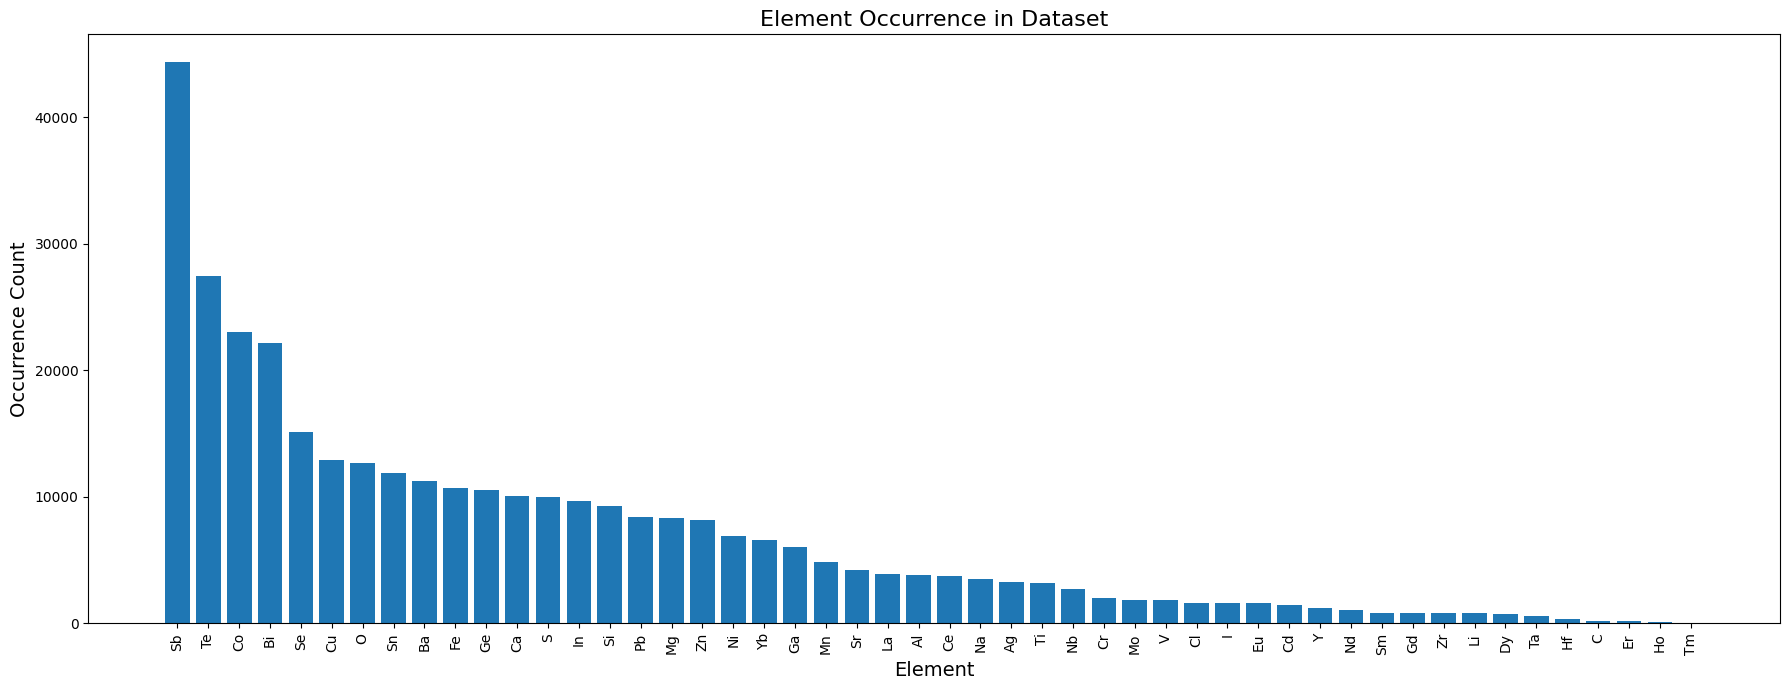

In [2]:
import pandas as pd
import re
from collections import Counter
import matplotlib.pyplot as plt

pattern = re.compile(r'([A-Z][a-z]?)')

all_elements = []

for formula in df["Formula"]:
    elements = pattern.findall(str(formula))
    all_elements.extend(elements)

element_counts = Counter(all_elements)

# Chuyển sang DataFrame
element_df = pd.DataFrame({
    "Element": list(element_counts.keys()),
    "Count": list(element_counts.values())
})

# Sắp xếp giảm dần
element_df = element_df.sort_values(
    by="Count",
    ascending=False
).reset_index(drop=True)

print(element_df)

# =========================
# Vẽ bar chart
# =========================
plt.figure(figsize=(18, 7))

plt.bar(
    element_df["Element"],
    element_df["Count"]
)

plt.xlabel("Element", fontsize=14)
plt.ylabel("Occurrence Count", fontsize=14)
plt.title("Element Occurrence in Dataset", fontsize=16)

plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

In [3]:
import re
import pandas as pd


PATTERN = re.compile(r'([A-Z][a-z]?)([0-9]*\.?[0-9]*)')

def formula_to_percent_dict(formula: str):
    """
    Trả về dict {nguyên_tố: %} với tổng = 100.
    Hỗ trợ: 'Pt', 'Cu0.5Ni99.5', 'Fe3Al', ...
    """
    f = str(formula).replace(" ", "")
    tokens = PATTERN.findall(f)
    if not tokens:
        raise ValueError(f"Không parse được công thức: {formula}")

    elems, amounts = [], []
    for el, num in tokens:
        elems.append(el)
        if num == "":
            amounts.append(1.0)
        else:
            amounts.append(float(num))

    # TH đặc biệt: 1 nguyên tố, không ghi hệ số -> 100%
    if len(elems) == 1 and tokens[0][1] == "":
        return {elems[0]: 100.0}

    total = sum(amounts)
    return {el: amt / total * 100.0 for el, amt in zip(elems, amounts)}

# 1) Tách công thức thành dict % nguyên tố
comp_dicts = df["Formula"].apply(formula_to_percent_dict)

# 2) Chuyển sang DataFrame các cột nguyên tố
comp_df = pd.DataFrame(comp_dicts.tolist()).fillna(0.0)

# 3) Ghép với các cột Temperature và Thermal conductivity từ df gốc
new_df = pd.concat(
    [
        df[["Formula", "Temperature (K)", "TC"]],
        comp_df
    ],
    axis=1
)

# (tuỳ chọn) kiểm tra tổng % = 100
print(new_df[comp_df.columns].sum(axis=1).describe())

# 4) Lưu ra file mới
new_df.to_csv("tc_with_composition_parsed.csv", index=False)
print("Đã lưu file: tc_with_composition_parsed.csv")


count    99772.000000
mean        99.603578
std          4.605337
min          6.325937
25%        100.000000
50%        100.000000
75%        100.000000
max        100.000000
dtype: float64
Đã lưu file: tc_with_composition_parsed.csv


In [4]:
import pandas as pd
import re
from collections import Counter
import matplotlib.pyplot as plt

high_tc_df = df[df["TC"] > 15]

print("Number of high-TC samples:", len(high_tc_df))

# =========================
# Regex parse nguyên tố
# =========================
pattern = re.compile(r'([A-Z][a-z]?)')

# =========================
# Đếm nguyên tố
# =========================
element_counter = Counter()

for formula in high_tc_df["Formula"]:

    elements = set(pattern.findall(str(formula)))

    element_counter.update(elements)

# =========================
# Chuyển sang DataFrame
# =========================
result_df = pd.DataFrame({
    "Element": list(element_counter.keys()),
    "Count": list(element_counter.values())
})

# sort giảm dần
result_df = result_df.sort_values(
    by="Count",
    ascending=False
)

print(result_df.head(20))

Number of high-TC samples: 1552
   Element  Count
10      Sb    451
2        O    440
1       Al    374
12      Bi    226
0       Fe    223
13      Se    202
7        V    186
25      In    173
5       Si    165
4       Cr    157
3       Mn    136
9       Co    132
31      Sr    131
16      Ca    126
6       Mg    125
8       Ti    116
32       Y    114
18      Cu    100
27      Mo     97
15      Te     65


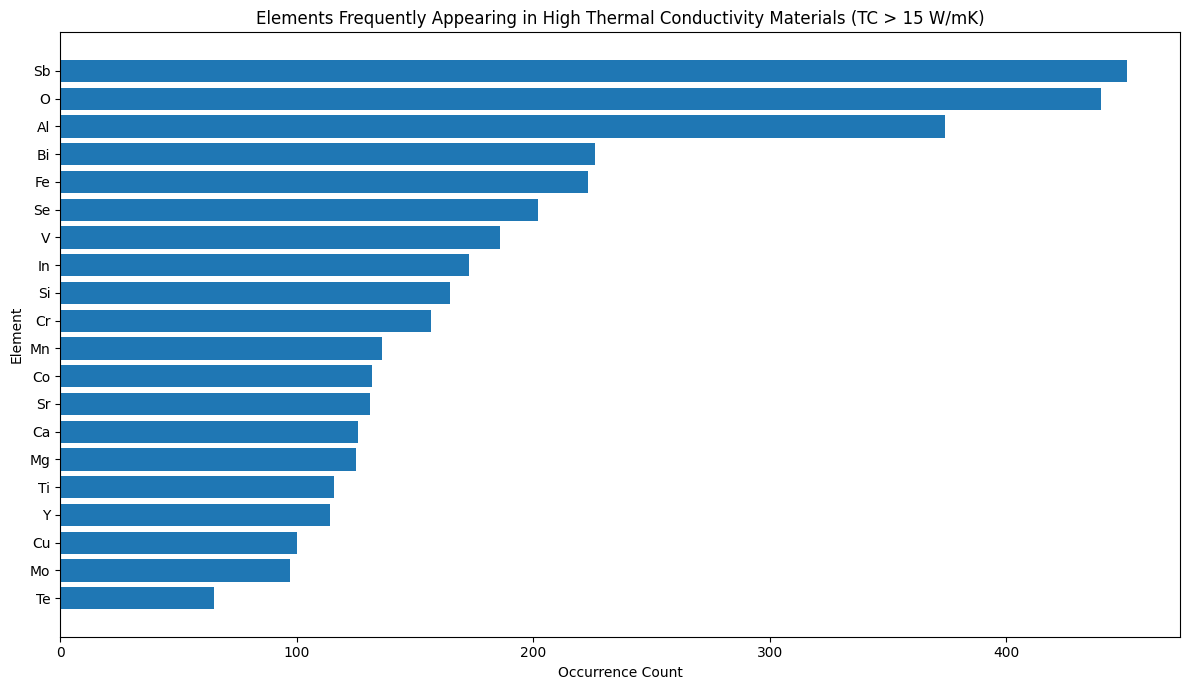

In [5]:
top_n = 20

top_df = result_df.head(top_n)

plt.figure(figsize=(12,7))

plt.barh(
    top_df["Element"],
    top_df["Count"]
)

plt.xlabel("Occurrence Count")
plt.ylabel("Element")

plt.title(
    "Elements Frequently Appearing in High Thermal Conductivity Materials (TC > 15 W/mK)"
)

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [6]:
# y = thermal conductivity
y = new_df["TC"]

# X = temperature + tất cả feature composition sinh ra
X = new_df.drop(columns=["TC", "Formula"])

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (99772, 51)
y shape: (99772,)


In [7]:
import pandas as pd
from sklearn.model_selection import train_test_split
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
import unicodedata



X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    shuffle=True
)



print("Train:", X_train.shape)
print("Test:", X_test.shape)


Train: (79817, 51)
Test: (19955, 51)


In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error

from sklearn.ensemble import ExtraTreesRegressor, RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR

from xgboost import XGBRegressor
! pip install catboost
from catboost import CatBoostRegressor


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [9]:

cv = KFold(n_splits=5, shuffle=True, random_state=42)

models_and_grids = {
    # "SVR": (
    #     SVR(),
    #     {
    #         "kernel": ["rbf"],
    #         "C": [1.0, 10.0, 100.0],
    #         "gamma": ["scale", 0.01, 0.1]
    #     }
    # ),
    # "KNN": (
    #     KNeighborsRegressor(),
    #     {
    #          'n_neighbors': [2, 3, 4, 5, 6, 7, 8 ,9, 10],
    #          'weights': ['uniform', 'distance'],
    #          'metric': ['euclidean', 'manhattan', 'minkowski']
    #     }
    # ),
    "DecisionTree": (
        DecisionTreeRegressor(random_state=42),
        {
            "max_depth": [None, 6, 12, 20],
            "min_samples_split": [2, 5, 10]
        }
    ),
    "RandomForest": (
        RandomForestRegressor(random_state=42, n_jobs=-1),
        {
            "n_estimators": [200, 500],
            "max_depth": [None, 12, 20],
            "min_samples_split": [2, 5]
        }
    ),
    "ExtraTrees": (
        ExtraTreesRegressor(random_state=42, n_jobs=-1),
        {
            "n_estimators": [300, 600],
            "max_depth": [None, 12, 20],
            "min_samples_split": [2, 5]
        }
    ),
    "GradientBoosting": (
        GradientBoostingRegressor(random_state=42),
        {
            "n_estimators": [200, 500],
            "learning_rate": [0.05, 0.1],
            "max_depth": [2, 3, 4]
        }
    ),
    
    "XGBoost": (
        XGBRegressor(
            random_state=42, n_estimators=300, tree_method="hist", n_jobs=-1,
            eval_metric="rmse"
        ),
        {
            "max_depth": [3, 5, 7],
            "learning_rate": [0.05, 0.1],
            "subsample": [0.8, 1.0],
            "colsample_bytree": [0.8, 1.0]
        }
    ),
    "CatBoost": (
        CatBoostRegressor(
            random_state=42, silent=True, loss_function="RMSE"
        ),
        {
            "iterations": [500, 800],
            "depth": [4, 6, 8],
            "learning_rate": [0.05, 0.1],
            "l2_leaf_reg": [1, 3, 5]
        }
    ),
}



In [10]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

results = []

# Hàm tính R2, RMSE, MAE đúng chuẩn
def r2_rmse_mae(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    return r2, rmse, mae

test_predictions = {}

for name, (estimator, grid) in models_and_grids.items():
    print(f"\n===== {name} =====")

    gs = GridSearchCV(
        estimator=estimator,
        param_grid=grid,
        scoring="neg_root_mean_squared_error",
        cv=cv,
        n_jobs=-1,
        refit=True,
        verbose=0
    )
    gs.fit(X_train, y_train)

    best = gs.best_estimator_

    # Predict
    y_pred_tr  = best.predict(X_train)
    y_pred_te  = best.predict(X_test)

    test_predictions[name] = y_pred_te

    # Metrics
    r2_tr,  rmse_tr,  mae_tr  = r2_rmse_mae(y_train, y_pred_tr)
    r2_te,  rmse_te,  mae_te  = r2_rmse_mae(y_test, y_pred_te)

    # Lưu kết quả
    results.append({
        "model": name,
        "best_params": gs.best_params_,

        "R2_train": r2_tr,   "RMSE_train": rmse_tr,   "MAE_train": mae_tr,
        "R2_test": r2_te,    "RMSE_test": rmse_te,    "MAE_test": mae_te
    })

# Kết quả DataFrame
res_df = pd.DataFrame(results).sort_values("RMSE_test")
res_df



===== DecisionTree =====

===== RandomForest =====

===== ExtraTrees =====

===== GradientBoosting =====

===== XGBoost =====

===== CatBoost =====


c:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\model_selection\_validation.py:490: FitFailedWarning: 
10 fits failed out of a total of 180.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
10 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\model_selection\_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\catboost\core.py", line 6178, in fit
    return self._fit(X, y, cat_features, text_features, embedding_features, None, graph, sample_weight, None, None, None, None, bas

,model,best_params,R2_train,RMSE_train,MAE_train,R2_test,RMSE_test,MAE_test
2,ExtraTrees,"{'max_depth': None, 'min_samples_split': 5, 'n...",0.964340,0.577684,0.185226,0.898712,0.981788,0.335198
5,CatBoost,"{'depth': 8, 'iterations': 800, 'l2_leaf_reg':...",0.914341,0.895329,0.472193,0.895163,0.998839,0.498848
4,XGBoost,"{'colsample_bytree': 1.0, 'learning_rate': 0.1...",0.913092,0.901837,0.488526,0.888657,1.029365,0.524378
1,RandomForest,"{'max_depth': None, 'min_samples_split': 5, 'n...",0.970738,0.523299,0.190286,0.885000,1.046136,0.372043
0,DecisionTree,"{'max_depth': None, 'min_samples_split': 10}",0.961015,0.604013,0.217421,0.856810,1.167334,0.432616
3,GradientBoosting,"{'learning_rate': 0.1, 'max_depth': 4, 'n_esti...",0.851660,1.178221,0.660120,0.831409,1.266646,0.680871


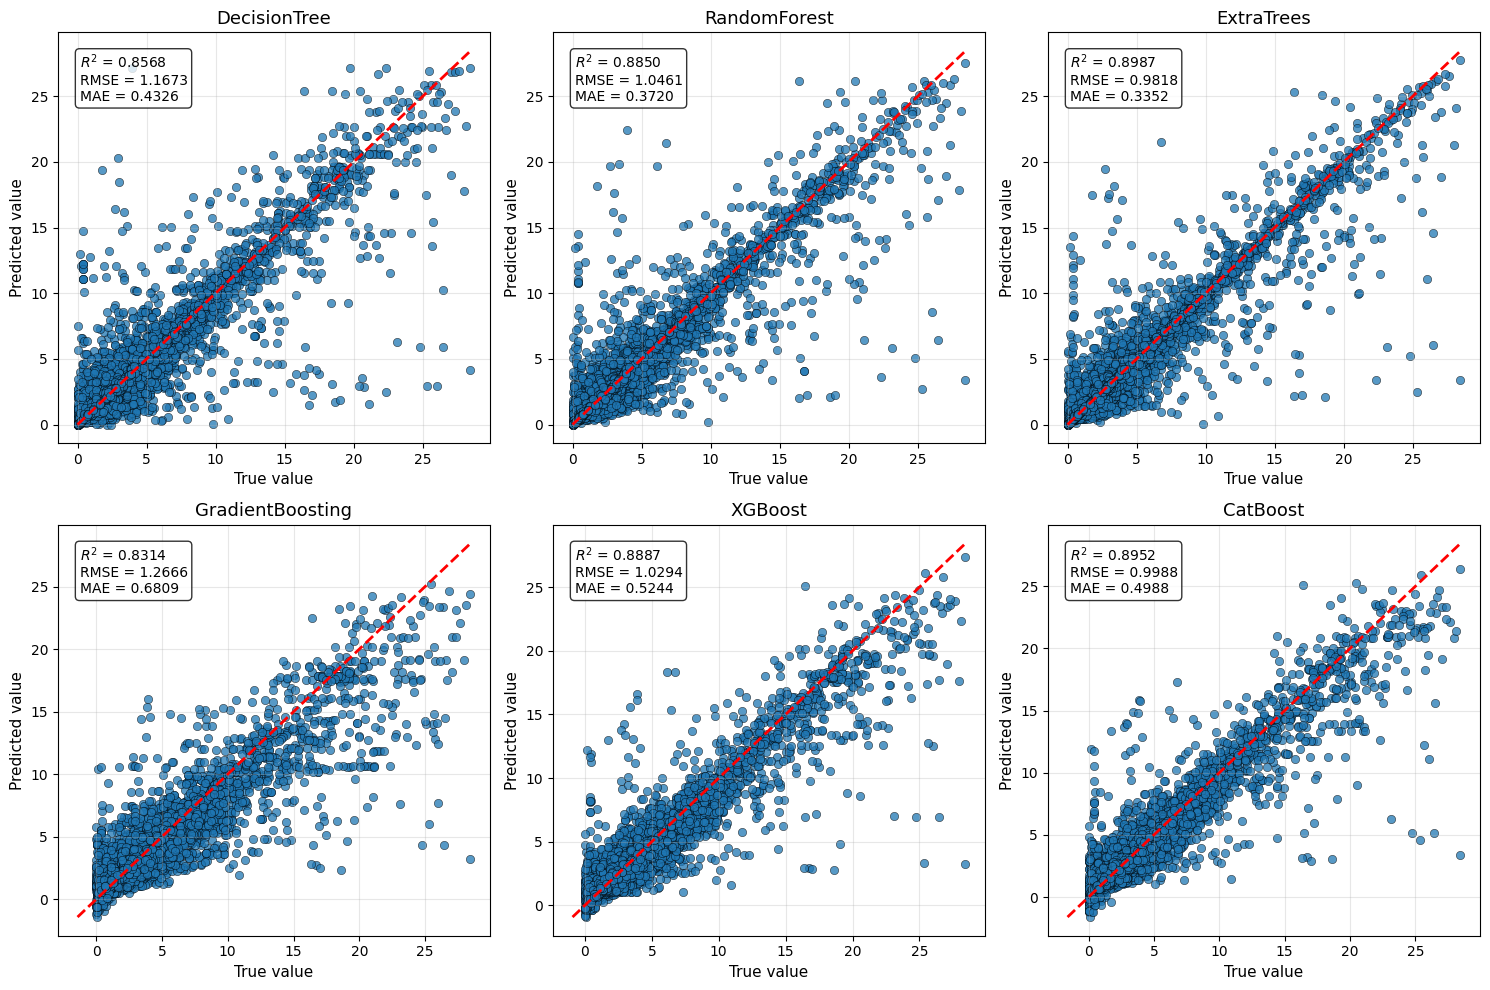

In [11]:
import os
import math
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

save_dir = "parity_plots"
os.makedirs(save_dir, exist_ok=True)

y_test_np = np.ravel(np.asarray(y_test))

# ===== subplot layout =====
ncols = 3
n_models = len(test_predictions)
nrows = math.ceil(n_models / ncols)

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(5*ncols, 5*nrows)
)

# flatten axes
axes = np.array(axes).reshape(-1)

# ===== plot =====
for ax, (name, y_pred) in zip(axes, test_predictions.items()):

    y_pred = np.ravel(y_pred)

    r2 = r2_score(y_test_np, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_np, y_pred))
    mae = mean_absolute_error(y_test_np, y_pred)

    min_val = min(y_test_np.min(), y_pred.min())
    max_val = max(y_test_np.max(), y_pred.max())

    # scatter
    ax.scatter(
        y_test_np,
        y_pred,
        alpha=0.75,
        edgecolor='k',
        linewidth=0.4
    )

    # parity line
    ax.plot(
        [min_val, max_val],
        [min_val, max_val],
        'r--',
        linewidth=2
    )

    ax.set_xlabel("True value", fontsize=11)
    ax.set_ylabel("Predicted value", fontsize=11)
    ax.set_title(name, fontsize=13)

    # metrics
    ax.text(
        0.05,
        0.95,
        f"$R^2$ = {r2:.4f}\nRMSE = {rmse:.4f}\nMAE = {mae:.4f}",
        transform=ax.transAxes,
        fontsize=10,
        verticalalignment='top',
        bbox=dict(
            boxstyle='round',
            facecolor='white',
            alpha=0.8
        )
    )

    ax.grid(alpha=0.3)

# ===== remove empty subplots =====
for i in range(len(test_predictions), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()

# ===== save =====
plt.savefig(
    f"{save_dir}/all_models_parity_subplot.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

best_row = res_df.iloc[0]
best_model_name = best_row["model"]
print(f"Best Model: {best_model_name}")
print("Best Params:", best_row["best_params"])

# Lấy class của model (CatBoostRegressor, RandomForestRegressor, v.v.)
model_class = type(models_and_grids[best_model_name][0])

# Khởi tạo model mới với best params
best_estimator = model_class(**best_row["best_params"])

# Fit lại model
best_estimator.fit(X_train, y_train)

feature_names = X.columns

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": best_estimator.feature_importances_
}).sort_values("importance", ascending=False)

importance_df

Best Model: ExtraTrees
Best Params: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 600}


,feature,importance
0,Temperature (K),0.229265
25,Al,0.106976
5,Sb,0.055506
28,Fe,0.055129
4,Se,0.046660
12,O,0.040110
6,In,0.034259
29,Cr,0.032561
2,Bi,0.032195
27,Si,0.030346


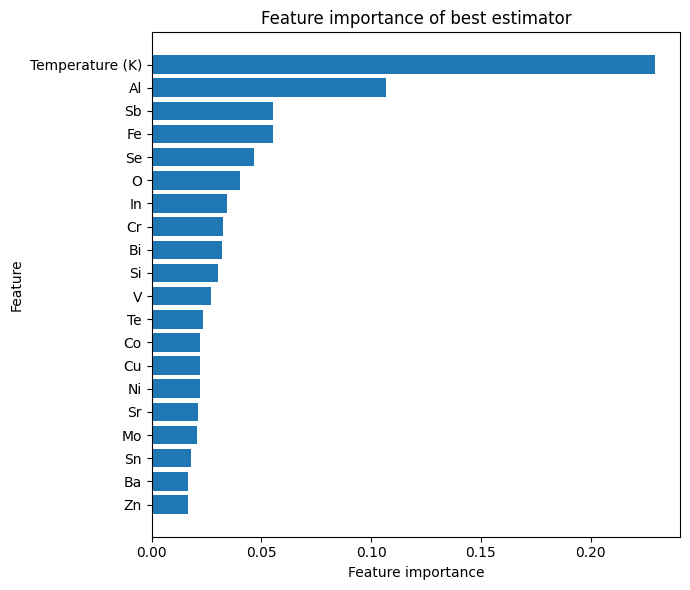

In [13]:
top_n = 20
plot_df = importance_df.head(top_n).iloc[::-1]

plt.figure(figsize=(7, 6))
plt.barh(plot_df["feature"], plot_df["importance"])

plt.xlabel("Feature importance")
plt.ylabel("Feature")
plt.title("Feature importance of best estimator")

plt.tight_layout()
plt.savefig("best_estimator_feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()

In [14]:
import re

PATTERN = re.compile(r'([A-Z][a-z]?)([0-9]*\.?[0-9]*)')

def formula_to_percent_dict(formula: str):
    f = str(formula).replace(" ", "")
    tokens = PATTERN.findall(f)
    if not tokens:
        raise ValueError(f"Không parse được công thức: {formula}")

    elems, amounts = [], []
    for el, num in tokens:
        elems.append(el)
        amounts.append(1.0 if num == "" else float(num))

    # 1 nguyên tố không hệ số -> 100%
    if len(elems) == 1 and tokens[0][1] == "":
        return {elems[0]: 100.0}

    total = sum(amounts)
    return {el: amt / total * 100.0 for el, amt in zip(elems, amounts)}

def make_feature_row(formula: str, temperature_K: float, feature_cols):
    comp = formula_to_percent_dict(formula)
    row = {c: 0.0 for c in feature_cols}
    if "Temperature (K)" not in row:
        raise ValueError("Thiếu cột 'Temperature (K)' trong feature_cols (X_train.columns).")

    row["Temperature (K)"] = float(temperature_K)

    # fill các nguyên tố có trong feature_cols
    for el, pct in comp.items():
        if el in row:
            row[el] = float(pct)
        # nếu el không có trong feature space thì bỏ qua (không crash)

    return pd.DataFrame([row], columns=feature_cols)

FEATURE_COLS = list(X_train.columns)


def predict_TC(formula: str, temperature_K: float):
    Xq = make_feature_row(formula, temperature_K, FEATURE_COLS)
    yhat = float(best_estimator.predict(Xq)[0])
    return yhat

In [15]:
predict_TC("Al2S2", 300)

14.363071886285521

In [16]:
import pandas as pd

# đọc file csv
df = pd.read_csv(r"C:\Users\Admin\Downloads\20220801_rawdata\AI for materials\gnn_basic_columns (1).csv")

# tạo cột mới để chứa TC dự đoán
df["TC_predicted"] = None

# vòng lặp dự đoán
for i, row in df.iterrows():
    formula = row["formula"]
    T = row["Temperature (K)"]

    # bỏ qua dòng thiếu dữ liệu
    if pd.isna(formula) or pd.isna(T):
        continue

    df.at[i, "TC_predicted"] = predict_TC(formula, float(T))

# df.to_csv("stainless_all_TC_with_type.csv", index=False)


df


,identifier,formula,Temperature (K),atoms,num_atoms,TC_predicted
0,mp-10009,Al2S2,300,"Atoms(symbols='Al2S2', pbc=True, cell=[[3.5853...",4,14.363072
1,mp-1001082,C4O4Si2,300,"Atoms(symbols='Si2C4O4', pbc=True, cell=[[2.93...",10,3.479885
2,mp-1001825,Be2Li2,300,"Atoms(symbols='Li2Be2', pbc=True, cell=[2.3629...",4,3.010841
3,mp-10021,In2,300,"Atoms(symbols='In2', pbc=True, cell=[3.0075920...",2,1.711509
4,mp-1002573,HMnO2,300,"Atoms(symbols='MnHO2', pbc=True, cell=[[2.9512...",4,3.946421
...,...,...,...,...,...,...
2933,mvc-9246,Mo6O14,300,"Atoms(symbols='Mo6O14', pbc=True, cell=[5.5986...",20,14.440746
2934,mvc-9397,Bi4O8,300,"Atoms(symbols='Bi4O8', pbc=True, cell=[[6.1900...",12,1.272934
2935,mvc-9477,O8Sb4,300,"Atoms(symbols='Sb4O8', pbc=True, cell=[[5.9218...",12,1.690869
2936,mvc-9642,N4O8,300,"Atoms(symbols='N4O8', pbc=True, cell=[[5.78976...",12,2.266298


In [18]:
import joblib

joblib.dump(best_estimator, "best_model_starry.pkl",)

['best_model_starry.pkl']